# Homework 5 Programming Question 1

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv('Boston.csv')
X = df.drop(columns=['medv'])
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42) #split 50/50 like the question asked
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test Mean Squared Error: {mse:.3f}")

Test Mean Squared Error: 28.682


In [2]:
from sklearn.ensemble import RandomForestRegressor

for n_trees in [25,100]:
    rf = RandomForestRegressor(n_estimators=n_trees, max_features=6, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    print(f"Random Forest ({n_trees} trees, m=6): Test MSE = {mse:.3f}")

Random Forest (25 trees, m=6): Test MSE = 28.682
Random Forest (100 trees, m=6): Test MSE = 28.682


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
median_crim = df['crim'].median()
df['HighCrime'] = (df['crim']>median_crim).astype(int)

X1 = df.drop(columns=["crim", "HighCrime"])
y1 = df["HighCrime"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.5, random_state=42)
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X1_train, y1_train)

y1_pred = tree_clf.predict(X1_test)
test_error = 1 - accuracy_score(y1_test, y1_pred)

print(f"Classification Tree Test Error: {test_error:.3f}")

Classification Tree Test Error: 0.079


In [11]:
from sklearn.ensemble import RandomForestClassifier

for n_trees in [25,100]:
    rf_clf = RandomForestClassifier(n_estimators=n_trees, max_features=6, random_state=42)
    rf_clf.fit(X1_train, y1_train)
    y1_pred_rf = rf_clf.predict(X1_test)
    test_error_rf = 1 - accuracy_score(y1_test, y1_pred_rf)
    print(f"Random Forest Classifier ({n_trees} trees, m=6): Test Error = {test_error_rf:.3f}")

Random Forest Classifier (25 trees, m=6): Test Error = 0.040
Random Forest Classifier (100 trees, m=6): Test Error = 0.043


# Programming Question 2

C=0.01: Cross-Validation Error = 0.105
C=0.1: Cross-Validation Error = 0.127
C=1: Cross-Validation Error = 0.119
C=10: Cross-Validation Error = 0.112
C=100: Cross-Validation Error = 0.109


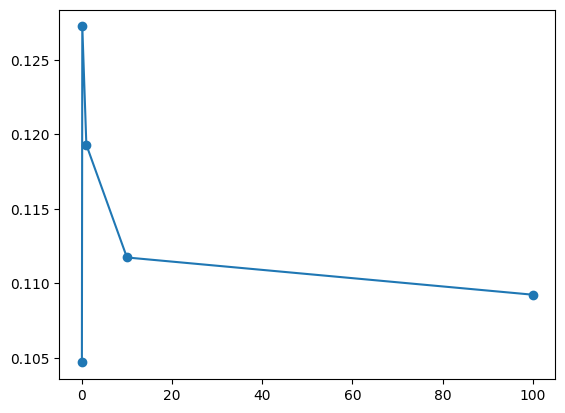

In [37]:
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv('Auto.csv')
median_mpg = df1['mpg'].median()
df1['HighMPG'] = (df1['mpg']>median_mpg).astype(int)
df1['horsepower'] = pd.to_numeric(df1['horsepower'], errors='coerce')
df1 = df1.dropna()

X2 = df1.drop(columns=['mpg','HighMPG','name'])
y2 = df1['HighMPG']
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
C_values = [0.01, 0.1, 1, 10, 100]
cv_errors = []

for C in C_values:
    svc = SVC(C=C, kernel='linear', random_state=42)
    scores = cross_val_score(svc, X2_scaled, y2, cv=10, scoring='accuracy')
    cv_error = 1 - scores.mean()
    if cv_errors is not None:
        cv_errors.append(cv_error)
        print(f"C={C}: Cross-Validation Error = {cv_error:.3f}")

plt.plot(C_values, cv_errors, marker='o', label='Linear')


RBF Kernel (Gamme Value=0.01, C=0.01): Cross-Validation Error = 0.477
RBF Kernel (Gamme Value=0.01, C=0.1): Cross-Validation Error = 0.120
RBF Kernel (Gamme Value=0.01, C=1): Cross-Validation Error = 0.112
RBF Kernel (Gamme Value=0.01, C=10): Cross-Validation Error = 0.132
RBF Kernel (Gamme Value=0.01, C=100): Cross-Validation Error = 0.122
RBF Kernel (Gamme Value=0.1, C=0.01): Cross-Validation Error = 0.145
RBF Kernel (Gamme Value=0.1, C=0.1): Cross-Validation Error = 0.102
RBF Kernel (Gamme Value=0.1, C=1): Cross-Validation Error = 0.130
RBF Kernel (Gamme Value=0.1, C=10): Cross-Validation Error = 0.114
RBF Kernel (Gamme Value=0.1, C=100): Cross-Validation Error = 0.124
RBF Kernel (Gamme Value=1, C=0.01): Cross-Validation Error = 0.477
RBF Kernel (Gamme Value=1, C=0.1): Cross-Validation Error = 0.115
RBF Kernel (Gamme Value=1, C=1): Cross-Validation Error = 0.101
RBF Kernel (Gamme Value=1, C=10): Cross-Validation Error = 0.122
RBF Kernel (Gamme Value=1, C=100): Cross-Validation Error

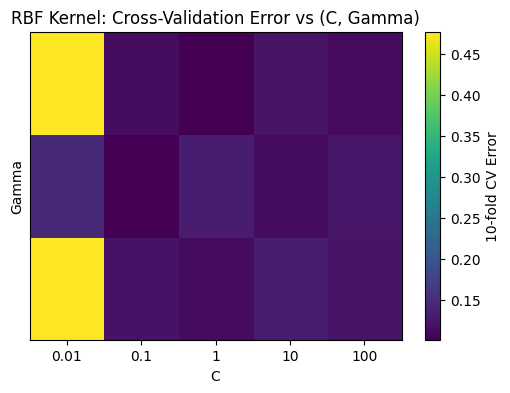

Poly Kernel (Degree=2, C=0.01): Cross-Validation Error = 0.477
Poly Kernel (Degree=2, C=0.1): Cross-Validation Error = 0.394
Poly Kernel (Degree=2, C=1): Cross-Validation Error = 0.257
Poly Kernel (Degree=2, C=10): Cross-Validation Error = 0.206
Poly Kernel (Degree=2, C=100): Cross-Validation Error = 0.239
Poly Kernel (Degree=3, C=0.01): Cross-Validation Error = 0.273
Poly Kernel (Degree=3, C=0.1): Cross-Validation Error = 0.161
Poly Kernel (Degree=3, C=1): Cross-Validation Error = 0.112
Poly Kernel (Degree=3, C=10): Cross-Validation Error = 0.086
Poly Kernel (Degree=3, C=100): Cross-Validation Error = 0.097
Poly Kernel (Degree=4, C=0.01): Cross-Validation Error = 0.411
Poly Kernel (Degree=4, C=0.1): Cross-Validation Error = 0.349
Poly Kernel (Degree=4, C=1): Cross-Validation Error = 0.277
Poly Kernel (Degree=4, C=10): Cross-Validation Error = 0.251
Poly Kernel (Degree=4, C=100): Cross-Validation Error = 0.173


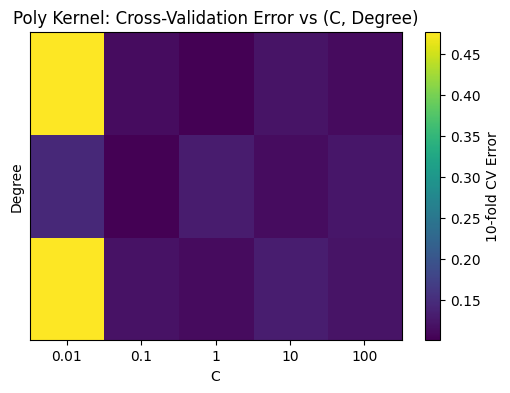

In [ ]:
gamma_values = [0.01,0.1,1]
degree_values = [2,3,4]
rbf_errors = np.zeros((len(gamma_values),len(C_values)))
poly_errors = np.zeros((len(gamma_values),len(C_values)))
for i, gamma_values in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        svc_rbf = SVC(kernel = 'rbf', C=C, gamma = gamma_values, random_state=42)
        scores_rbf = cross_val_score(svc_rbf, X2_scaled, y2, cv=10)
        rbf_errors[i,j] = 1 - scores_rbf.mean()
        print(f"RBF Kernel (Gamma Value={gamma_values}, C={C}): Cross-Validation Error = {rbf_errors[i,j]:.3f}")

plt.figure(figsize=(6,4))
plt.imshow(rbf_errors, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='10-fold CV Error')
plt.xticks(range(len(C_values)), C_values)
plt.yticks(range(3, gamma_values))
plt.xlabel('C')
plt.ylabel('Gamma')
plt.title('RBF Kernel: Cross-Validation Error vs (C, Gamma)')
plt.show()

for i, degree_values in enumerate(degree_values):
    for j, C in enumerate(C_values):
        svc_poly = SVC(kernel='poly', C=C, degree=degree_values, random_state=42)
        scores_poly = cross_val_score(svc_poly, X2_scaled, y2, cv=10)
        poly_errors[i,j] = 1 - scores_poly.mean()
        print(f"Poly Kernel (Degree={degree_values}, C={C}): Cross-Validation Error = {poly_errors[i,j]:.3f}")

plt.figure(figsize=(6,4))
plt.imshow(rbf_errors, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='10-fold CV Error')
plt.xticks(range(len(C_values)), C_values)
plt.yticks(range(3, gamma_values))
plt.xlabel('C')
plt.ylabel('Degree')
plt.title('Poly Kernel: Cross-Validation Error vs (C, Degree)')
plt.show()


# Programming Question 3

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split

df2 = pd.read_csv('OJ.csv')
train_df2, test_df2 = train_test_split(df2, train_size = 800, random_state = 42)


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X2_train = train_df2.drop(columns=['Purchase'])
y2_train = train_df2['Purchase']

X2_train = pd.get_dummies(X2_train, drop_first=True)
X2_train_scaled = scaler.fit_transform(X2_train)

svc_model = SVC(kernel='linear', C=0.01, random_state=42)
svc_model.fit(X2_train_scaled, y2_train)
num_support_vectors = svc_model.n_support_.sum()
print("Number of support vectors:", num_support_vectors)

Number of support vectors: 430


In [54]:
X2_test = test_df2.drop(columns=['Purchase'])
X2_test = pd.get_dummies(X2_test, drop_first=True)

X2_test_scaled = scaler.transform(X2_test)
y2_pred_train = svc_model.predict(X2_train_scaled)
y2_pred_test = svc_model.predict(X2_test_scaled)
y2_test = test_df2['Purchase']

train_error = 1 - accuracy_score(y2_train, y2_pred_train)
test_error = 1 - accuracy_score(y2_test, y2_pred_test)

print(f"Training Error: {train_error:.3f}")
print(f"Test Error: {test_error:.3f}")

Training Error: 0.160
Test Error: 0.196


In [62]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
svm = SVC(kernel='linear', random_state=42)

grid_search = GridSearchCV(svm, param_grid, cv=10)
grid_search.fit(X2_train_scaled, y2_train)

best_C = grid_search.best_params_['C']
print(f"Optimal C value: {best_C}")
rbf_best_c = SVC(kernel='rbf', C=best_C, random_state=42)
rbf_best_c.fit(X2_train_scaled, y2_train )
y2_pred_rbf = rbf_best_c.predict(X2_train_scaled)
y2_test_rbf = rbf_best_c.predict(X2_test_scaled)

train_error_rbf_best_c = 1- accuracy_score(y2_train, y2_pred_rbf)
test_error_rbf_best_c = 1 - accuracy_score(y2_test, y2_test_rbf)
print(f"RBF kernel - Training error: {train_error_rbf_best_c:.3f}")
print(f"RBF kernel - Test error: {test_error_rbf_best_c:.3f}")
print(f"Number of support vectors: {rbf_best_c.n_support_.sum()}")

poly_best_c = SVC(kernel='poly', C=best_C, random_state=42)
poly_best_c.fit(X2_train_scaled, y2_train )
y2_pred_poly = poly_best_c.predict(X2_train_scaled)
y2_test_poly = poly_best_c.predict(X2_test_scaled)
train_error_poly_best_c = 1 - accuracy_score(y2_train, y2_pred_poly)
test_error_poly_best_c = 1 - accuracy_score(y2_test, y2_test_poly)
print(f"Poly kernel - Training error: {train_error_poly_best_c:.3f}")
print(f"Poly kernel - Test error: {test_error_poly_best_c:.3f}")
print(f"Number of support vectors: {rbf_best_c.n_support_.sum()}")


Optimal C value: 0.01
RBF kernel - Training error: 0.382
RBF kernel - Test error: 0.411
Number of support vectors: 617
Poly kernel - Training error: 0.361
Poly kernel - Test error: 0.393
Number of support vectors: 617


In [60]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}  # gamma uses default (1 / #features)
svm_rbf = SVC(kernel='rbf', random_state=42)

grid_rbf = GridSearchCV(svm_rbf, param_grid, cv=10)
grid_rbf.fit(X2_train_scaled, y2_train)

best_C_rbf = grid_rbf.best_params_['C']
print(f"Best C for RBF kernel: {best_C_rbf}")

rbf_best = SVC(kernel='rbf', C=best_C_rbf, random_state=42)
rbf_best.fit(X2_train_scaled, y2_train)

y2_pred_train_rbf = rbf_best.predict(X2_train_scaled)
y2_pred_test_rbf = rbf_best.predict(X2_test_scaled)

train_error_rbf = 1 - accuracy_score(y2_train, y2_pred_train_rbf)
test_error_rbf = 1 - accuracy_score(y2_test, y2_pred_test_rbf)

print(f"RBF kernel - Training error: {train_error_rbf:.3f}")
print(f"RBF kernel - Test error: {test_error_rbf:.3f}")
print(f"Number of support vectors: {rbf_best.n_support_.sum()}")

Best C for RBF kernel: 1
RBF kernel - Training error: 0.146
RBF kernel - Test error: 0.189
Number of support vectors: 366


In [61]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
svm_poly = SVC(kernel='poly', degree=2, random_state=42)

grid_poly = GridSearchCV(svm_poly, param_grid, cv=10)
grid_poly.fit(X2_train_scaled, y2_train)

best_C_poly = grid_poly.best_params_['C']
print(f"Best C for Polynomial (degree=2) kernel: {best_C_poly}")

poly_best = SVC(kernel='poly', degree=2, C=best_C_poly, random_state=42)
poly_best.fit(X2_train_scaled, y2_train)

y2_pred_train_poly = poly_best.predict(X2_train_scaled)
y2_pred_test_poly = poly_best.predict(X2_test_scaled)

train_error_poly = 1 - accuracy_score(y2_train, y2_pred_train_poly)
test_error_poly = 1 - accuracy_score(y2_test, y2_pred_test_poly)

print(f"Poly kernel - Training error: {train_error_poly:.3f}")
print(f"Poly kernel - Test error: {test_error_poly:.3f}")
print(f"Number of support vectors: {poly_best.n_support_.sum()}")

Best C for Polynomial (degree=2) kernel: 5
Poly kernel - Training error: 0.203
Poly kernel - Test error: 0.252
Number of support vectors: 452
